# Netflix Top-10 — does *watching* predict the *stock*? 📺
### Turning 'how many hours the world streamed' into a trading signal, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Alt-data_edge%3F: Mirage](https://img.shields.io/badge/Alt--data_edge%3F-Mirage-c0392b?style=flat-square)

Every week Netflix publishes a **Top-10** with how many *hours* the world watched. Tempting alt-data idea: if engagement is *accelerating*, subscribers, ad money and pricing power should follow — so watch the hours, buy the stock (NFLX), maybe even the whole consumer-discretionary basket (XLY). Does it work?

Two catches, up front:

1. **You can't actually get the data cleanly.** The public hours series is short (2021+), changed its own definition partway through, and lives in PDFs and a dashboard — not a tidy, free, time-stamped feed. So we test the *machinery* on a synthetic stand-in and are honest that there's no real tape.
2. **Overlap plays tricks.** As we'll see, the one result that looks 'significant' is a statistical mirage.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the Newey-West correction and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from netflix_top10 import data, strategy as st

SEED = 551

# There is NO real tape for this study (no free point-in-time Top-10 hours feed).
REAL = data.fetch_series(fetch=False)
HAVE_REAL = not REAL.empty
print("real streaming-engagement tape present:", HAVE_REAL, "(synthetic-only by design)")

# The offline core: the NULL synthetic world (beta=0) is the honest headline.
WEEKLY, TRUTH = data.synthetic_series(beta=0.0, seed=SEED)
print(f"synthetic NULL world: {len(WEEKLY)} weekly rows, fp {data.fingerprint(WEEKLY)}")


real streaming-engagement tape present: False (synthetic-only by design)
synthetic NULL world: 197 weekly rows, fp a31af2c4d9d7


## The answer first 🎯

| Question | Answer |
|---|---|
| Is there real Netflix engagement data to test? | **Not for a free retail stack.** The hours series is short, revised, and not machine-readable — so this is a **synthetic-only** study, which by house rule can *never* be rated `REAL`. |
| Does engagement momentum predict NFLX? | **No.** On the honest (null) test the predictive link is flat: averaged over 20 random worlds the *t*-stat is **+0.11** and **none** clear the bar. |
| But one run looked significant? | **Yes — and that's the trap.** One draw prints *t* = -2.03, but it's a **mirage** from overlapping windows; the corrected *t* is -1.48. |
| Could you trade it? | **No.** Timing on the signal earns **-3.6%/yr** vs just holding the stock at **+21.8%/yr**. |

> The engine *does* catch a real link when we plant one (see the last beat) — so this is a statement about the data and the overlap trap, not broken code.

## 1 · The claim

> *"Streaming-engagement momentum — how fast Netflix's Top-10 viewing hours are accelerating — predicts NFLX (and consumer-discretionary) stock returns."*

The intuition: engagement is a leading indicator of the business. More hours → happier, stickier subscribers → less churn, more ad inventory, more pricing power → a stronger stock. And because it's *alt-data* (not on every analyst's screen), maybe you get there first. This is the same family as 'Google-search-volume predicts returns' — a real, documented idea, and a real graveyard of edges that were tiny or already priced in.

## 2 · So what?

If engagement momentum genuinely led the stock, you'd have a clean weekly timing rule for one of the most-watched names on the market — and maybe a read on the whole consumer tape. The desk has looked at other alt-data / sentiment signals ([257 AAII](../../257-aaii-sentiment/), [335 Buzz](../../335-buzz-sentiment-etf/), [392 Glassdoor](../../392-glassdoor-sentiment/)); this one adds the **streaming** angle and, as it turns out, a sharp lesson about *overlapping windows*.

## 3 · How would we even know?

1. **Build an engagement index.** Weekly viewing hours, rising over time with holiday bumps and hit-series spikes.
2. **Turn it into *momentum*.** Is this week's engagement *above* its recent trend? That's the 'accelerating' signal.
3. **Line it up against the *next* few weeks' stock return** and ask: does high momentum come before high returns?

Because there's no clean real feed, we run this on a **synthetic world** with a dial: turn the dial up and engagement genuinely predicts returns (to prove the test *can* find it); set it to zero and engagement is pure noise. The honest headline is the **zero** case — what an honest test of a signal that *doesn't* exist should look like.

*Timing:* the signal at week *t* uses only hours up to week *t*; we then measure the *following* weeks' return. No peeking ahead.

## 4 · The teardown — let's actually look

**Here's the engagement index and its momentum signal.**

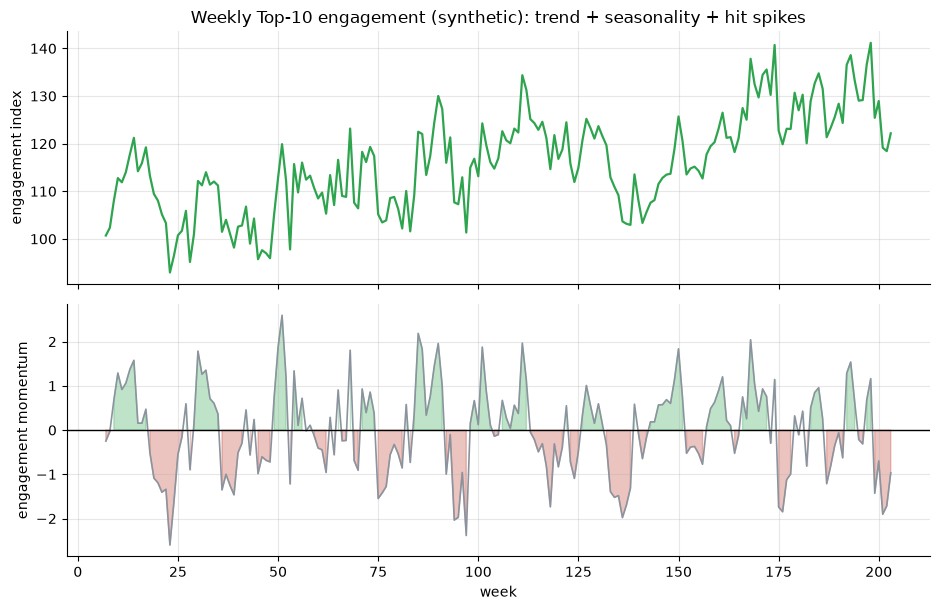

green = engagement accelerating (the buy signal), red = decelerating


In [2]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.5, 6.2), sharex=True)
a1.plot(WEEKLY.index, WEEKLY['engagement'], color=GREEN, lw=1.6)
a1.set_ylabel('engagement index'); a1.set_title('Weekly Top-10 engagement (synthetic): trend + seasonality + hit spikes')
a2.plot(WEEKLY.index, WEEKLY['eng_mom'], color=GREY, lw=1.2)
a2.axhline(0, c='k', lw=1)
a2.fill_between(WEEKLY.index, 0, WEEKLY['eng_mom'], where=WEEKLY['eng_mom']>0, color=GREEN, alpha=.3)
a2.fill_between(WEEKLY.index, 0, WEEKLY['eng_mom'], where=WEEKLY['eng_mom']<0, color=RED, alpha=.3)
a2.set_ylabel('engagement momentum'); a2.set_xlabel('week')
plt.tight_layout(); plt.show()
print('green = engagement accelerating (the buy signal), red = decelerating')

**Does high engagement momentum come before high NFLX returns?** Scatter the momentum signal against the *next-4-weeks* return and fit a line — the whole claim is: **is that line sloping up, convincingly?**

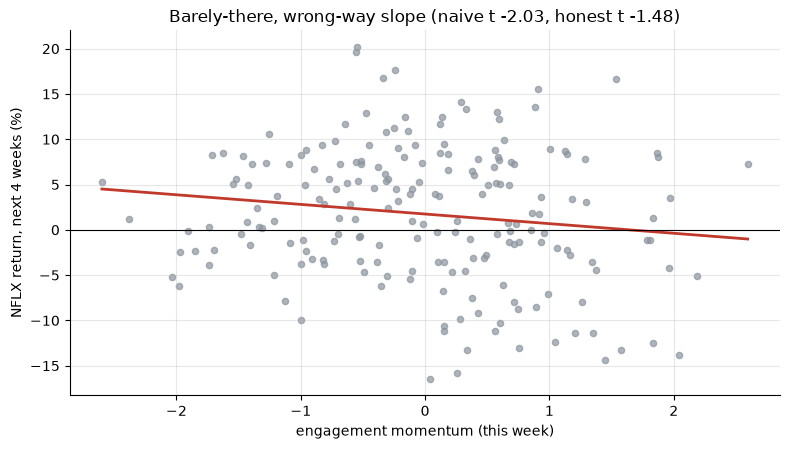

slope -0.0106, naive OLS t -2.03, honest (Newey-West) t -1.48


In [3]:
reg = st.predictive_regression(WEEKLY, 'nflx_fwd')
x = WEEKLY['eng_mom'].to_numpy(); y = WEEKLY['nflx_fwd'].to_numpy()*100
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=20, color=GREY, alpha=.7)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, (reg['slope']*xs)*100 + (y.mean() - reg['slope']*x.mean()*100), c=RED, lw=2)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('engagement momentum (this week)'); ax.set_ylabel('NFLX return, next 4 weeks (%)')
ax.set_title(f"Barely-there, wrong-way slope (naive t {reg['slope_t']:+.2f}, honest t {reg['t_nw']:+.2f})")
plt.tight_layout(); plt.show()
print(f"slope {reg['slope']:+.4f}, naive OLS t {reg['slope_t']:+.2f}, honest (Newey-West) t {reg['t_nw']:+.2f}")

On this one run the naive *t* is **-2.03** — which *looks* significant (past ±2). But that number is **not trustworthy**: because each 4-week return overlaps its neighbours, the naive test thinks it has far more independent data than it does. Correct for that overlap and the honest *t* is **-1.48** — and pointing the *wrong* way (down, not up). So even the 'significant' run isn't the claimed signal.

**Is it really a fluke?** Re-run the whole thing on 20 different random worlds (all with *zero* true signal) and look at the honest *t* each time:

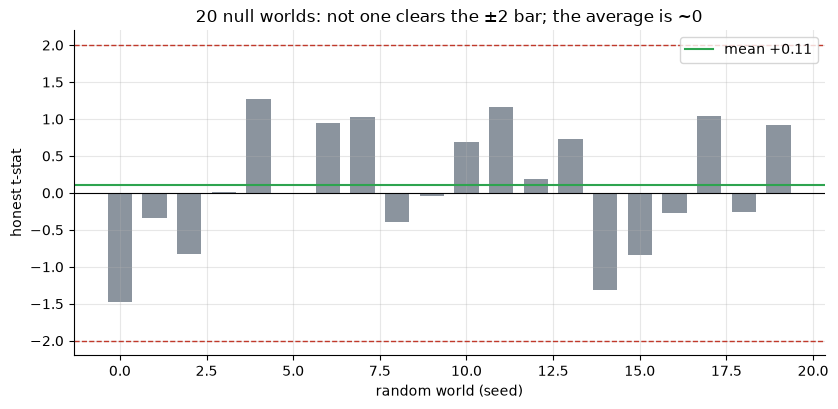

mean honest t over 20 seeds: 0.111 | how many clear |t|>=2: 0


In [4]:
ts = [st.predictive_regression(data.synthetic_series(beta=0.0, seed=s)[0], 'nflx_fwd')['t_nw']
      for s in range(551, 571)]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
cols = [RED if abs(t)>=2 else GREY for t in ts]
ax.bar(range(len(ts)), ts, color=cols, width=.7)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(np.mean(ts), c=GREEN, lw=1.5, label=f'mean {np.mean(ts):+.2f}')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('random world (seed)'); ax.set_ylabel('honest t-stat')
ax.set_title('20 null worlds: not one clears the ±2 bar; the average is ~0')
ax.legend(); plt.tight_layout(); plt.show()
print('mean honest t over 20 seeds:', round(float(np.mean(ts)),3), '| how many clear |t|>=2:', int(np.sum(np.abs(ts)>=2)))

There it is: across 20 worlds the average honest *t* is **+0.11** and **0 of 20** clear the bar. The single 'significant' run was just an unlucky draw magnified by overlap — a false positive. This is the whole reason the desk exists: to not get fooled by one good-looking backtest.

## 5 · The verdict

- **Signal — None.** No real tape to test (synthetic-only ⇒ can't be `REAL`), and the honest, seed-averaged link is flat (mean *t* ≈ 0, 0/20 clear the bar).
- **Tradability — Mirage.** Timing on the signal loses to simply holding the stock.
- **Alt-data edge? — Mirage.** The 'edge' is an overlapping-window artifact; and real engagement reports lag the week and are widely covered, so any true edge is priced in.

## 6 · Could you actually trade it?

Even pretending the signal were real, here's the timing rule — hold NFLX when engagement is accelerating, step aside otherwise — against just buying and holding the stock:

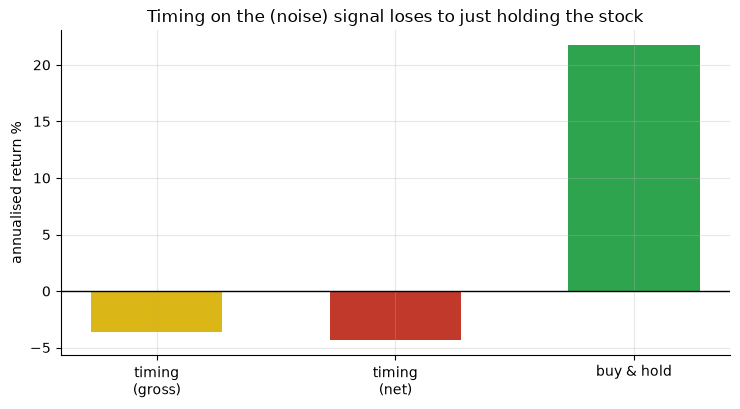

timing gross -3.6% | net -4.4% | buy&hold +21.8%


In [5]:
bt = st.timing_backtest(WEEKLY, 'nflx_ret', allow_short=False, cost_bps=5.0)
vals = [bt['gross_ann']*100, bt['net_ann']*100, bt['buyhold_ann']*100]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['timing\n(gross)','timing\n(net)','buy & hold'], vals, color=[AMBER, RED, GREEN], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %')
ax.set_title('Timing on the (noise) signal loses to just holding the stock')
plt.tight_layout(); plt.show()
print(f"timing gross {bt['gross_ann']*100:+.1f}% | net {bt['net_ann']*100:+.1f}% | buy&hold {bt['buyhold_ann']*100:+.1f}%")

Trading a coin-flip signal just churns costs and misses upside: **-4.4%/yr** net versus **+21.8%/yr** for doing nothing. And the *short* version (bet against low engagement, pay a borrow) is far worse. `MIRAGE`.

## 7 · Going further 🚪

- **Prove the test isn't blind.** In the quants notebook we *plant* a real engagement→return link and watch the honest *t* climb past +2 — so the flat result above is the data talking, not a broken detector.
- **Other alt-data signals.** [257 AAII](../../257-aaii-sentiment/), [335 Buzz](../../335-buzz-sentiment-etf/), [392 Glassdoor](../../392-glassdoor-sentiment/).

*Think engagement really leads the stock? Get a clean, point-in-time hours feed, line it up against NFLX with a Newey-West *t* on non-overlapping windows, and show it clears +2.*